In [25]:
# %% imports y rutas
from pathlib import Path
import pandas as pd
import numpy as np

SCENES_DIR   = Path("datos_sliding - copia")          # Escena1/, Escena2/, …
BATTERY_LOG  = Path("battery_data2.tsv")        # iso_ts\tlevel_pct

OUT_CSV      = Path("battery_by_scene.csv")

# %% cargar log de batería
bat = pd.read_csv(BATTERY_LOG, sep="\t", header=0)
bat["ts_dt"] = pd.to_datetime(bat["timestamp"])
bat = bat.set_index("ts_dt").sort_index()

# %% función de nivel interpolado
def level_at(ts_epoch):
    ts_dt = pd.to_datetime(ts_epoch, unit="s")
    return bat["battery_level"].reindex(bat.index.union([ts_dt])).interpolate("time").loc[ts_dt]

# %% recorrer escenas y calcular consumo
rows = []
for esc_dir in sorted(SCENES_DIR.glob("config*")):
    esc = esc_dir.name
    # leer todos los TSV 1 Hz de la escena
    epochs = []
    for tsv in esc_dir.glob("*.tsv"):
        df = pd.read_csv(tsv, sep="\t", header=None,
                         names=["epoch","dist","rssi"])
        epochs.append(df["epoch"])
    if not epochs:
        continue
    ep_concat = pd.concat(epochs)
    start, end = ep_concat.min(), ep_concat.max()

    lvl_start = level_at(start)
    lvl_end   = level_at(end)
    consumption = lvl_start - lvl_end

    rows.append((esc, start, end, lvl_start, lvl_end, consumption))
    print(f"{esc}: {lvl_start:.1f}% → {lvl_end:.1f}%   -∆ = {consumption:.2f}%")

# %% guardar CSV resumen
out_df = pd.DataFrame(rows,
    columns=["Escena","epoch_start","epoch_end",
             "level_start","level_end","consumption_pct"])
out_df.to_csv(OUT_CSV, index=False)
print(f"\n✅ Resumen guardado en {OUT_CSV}")

config1: 100.0% → 87.0%   -∆ = 13.00%
config2: 100.0% → 93.0%   -∆ = 7.00%
config3: 100.0% → 95.0%   -∆ = 4.99%
config4: 100.0% → 95.0%   -∆ = 5.00%
config5: 100.0% → 96.0%   -∆ = 4.00%
config6: 100.0% → 96.0%   -∆ = 3.99%

✅ Resumen guardado en battery_by_scene.csv


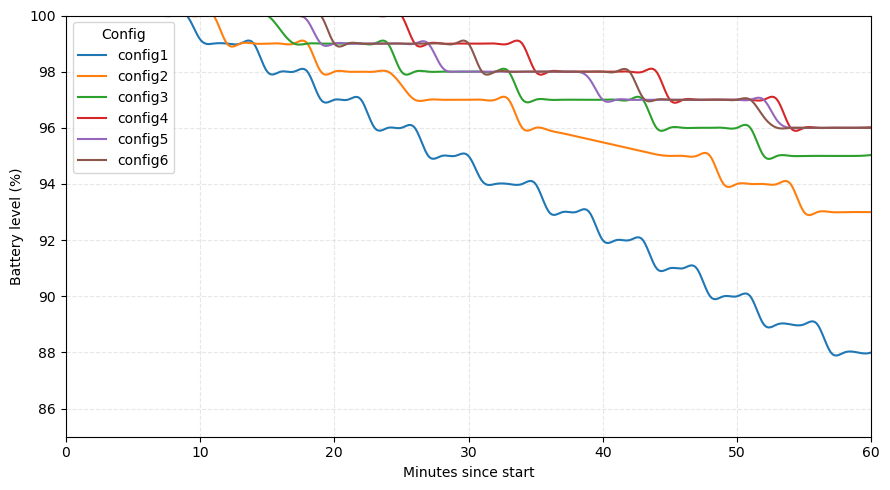

In [21]:
# %%  🔋 Battery-per-scene con líneas suaves (splines)
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

SCENES_DIR  = Path("datos_sliding - copia")          # Escena1/, Escena2/, …
BATTERY_LOG = Path("battery_data.tsv")        # timestamp \t level_pct

# --- leer log de batería ---------------------------------------------------
bat = (pd.read_csv(BATTERY_LOG, sep="\t", header=0)
         .rename(columns={"timestamp": "iso", "battery_level": "level"}))
bat["ts_dt"] = pd.to_datetime(bat["iso"])
bat = bat.set_index("ts_dt").sort_index()

def level_at(ts):            # interpolación lineal
    return (bat["level"]
            .reindex(bat.index.union([ts]))
            .interpolate("time")
            .loc[ts])

# --- preparar gráfico ------------------------------------------------------
fig, ax = plt.subplots(figsize=(9,5))
ax.set_xlim(0, 60);  ax.set_xlabel("Minutes since start")
ax.set_ylim(85, 100); ax.set_ylabel("Battery level (%)")
ax.grid(True, ls="--", alpha=.3)

# --- recorrer escenas ------------------------------------------------------
for esc_dir in sorted(SCENES_DIR.glob("config*")):
    esc = esc_dir.name
    epochs = [pd.read_csv(f, sep="\t", header=None)[0]
              for f in esc_dir.glob("*.tsv")]
    if not epochs:
        continue
    ep = pd.concat(epochs)
    t_start = pd.to_datetime(ep.min(), unit="s")
    t_end   = pd.to_datetime(ep.max(), unit="s")

    # rejilla cada minuto (0–60) o hasta fin de log
    mins = np.arange(0, 61)
    dts  = t_start + pd.to_timedelta(mins, unit="m")
    lvls = np.array([level_at(t) for t in dts])

    # --- spline cúbica para suavizar ---
    mask = ~np.isnan(lvls)            # evita NaN (p.ej. fuera del log)
    x    = mins[mask]
    y    = lvls[mask]

    if len(x) < 4:                    # spline necesita ≥4 puntos
        ax.plot(x, y, label=esc); continue

    spline = make_interp_spline(x, y, k=3)
    x_smooth = np.linspace(x.min(), x.max(), 400)
    y_smooth = spline(x_smooth)

    ax.plot(x_smooth, y_smooth, label=esc)

ax.legend(title="Config")
plt.tight_layout(); plt.show()

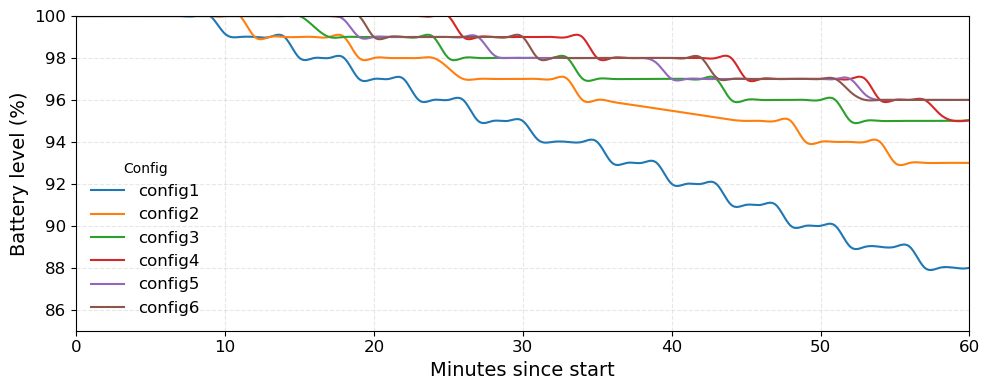

In [26]:
# %% 🔋 Battery-per-scene con líneas suaves (splines) — letras grandes
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

SCENES_DIR  = Path("datos_sliding - copia")
BATTERY_LOG = Path("battery_data2.tsv")

# ── leer log de batería ─────────────────────────────────────────────
bat = (pd.read_csv(BATTERY_LOG, sep="\t", header=0)
         .rename(columns={"timestamp": "iso", "battery_level": "level"}))
bat["ts_dt"] = pd.to_datetime(bat["iso"])
bat = bat.set_index("ts_dt").sort_index()

def level_at(ts):
    return (bat["level"]
            .reindex(bat.index.union([ts]))
            .interpolate("time")
            .loc[ts])

# ── preparar gráfico ───────────────────────────────────────────────
plt.rcParams.update({"axes.titlesize": 16,
                     "axes.labelsize": 14,
                     "xtick.labelsize": 12,
                     "ytick.labelsize": 12,
                     "legend.fontsize": 12})

fig, ax = plt.subplots(figsize=(10, 4))        # más ancho, menos alto
ax.set_xlim(0, 60);  ax.set_xlabel("Minutes since start")
ax.set_ylim(85, 100); ax.set_ylabel("Battery level (%)")
ax.grid(True, ls="--", alpha=.3)

# ── recorrer escenas ───────────────────────────────────────────────
for esc_dir in sorted(SCENES_DIR.glob("config*")):
    esc = esc_dir.name
    epochs = [pd.read_csv(f, sep="\t", header=None)[0]
              for f in esc_dir.glob("*.tsv")]
    if not epochs:
        continue
    ep = pd.concat(epochs)
    t_start = pd.to_datetime(ep.min(), unit="s")

    mins = np.arange(0, 61)
    dts  = t_start + pd.to_timedelta(mins, unit="m")
    lvls = np.array([level_at(t) for t in dts])

    mask = ~np.isnan(lvls)
    x, y = mins[mask], lvls[mask]

    if len(x) < 4:
        ax.plot(x, y, label=esc); continue

    spline = make_interp_spline(x, y, k=3)
    x_smooth = np.linspace(x.min(), x.max(), 400)
    y_smooth = spline(x_smooth)

    ax.plot(x_smooth, y_smooth, label=esc)

ax.legend(title="Config", loc="lower left", frameon=False)
plt.savefig("battery_per_scene.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()